# DAO

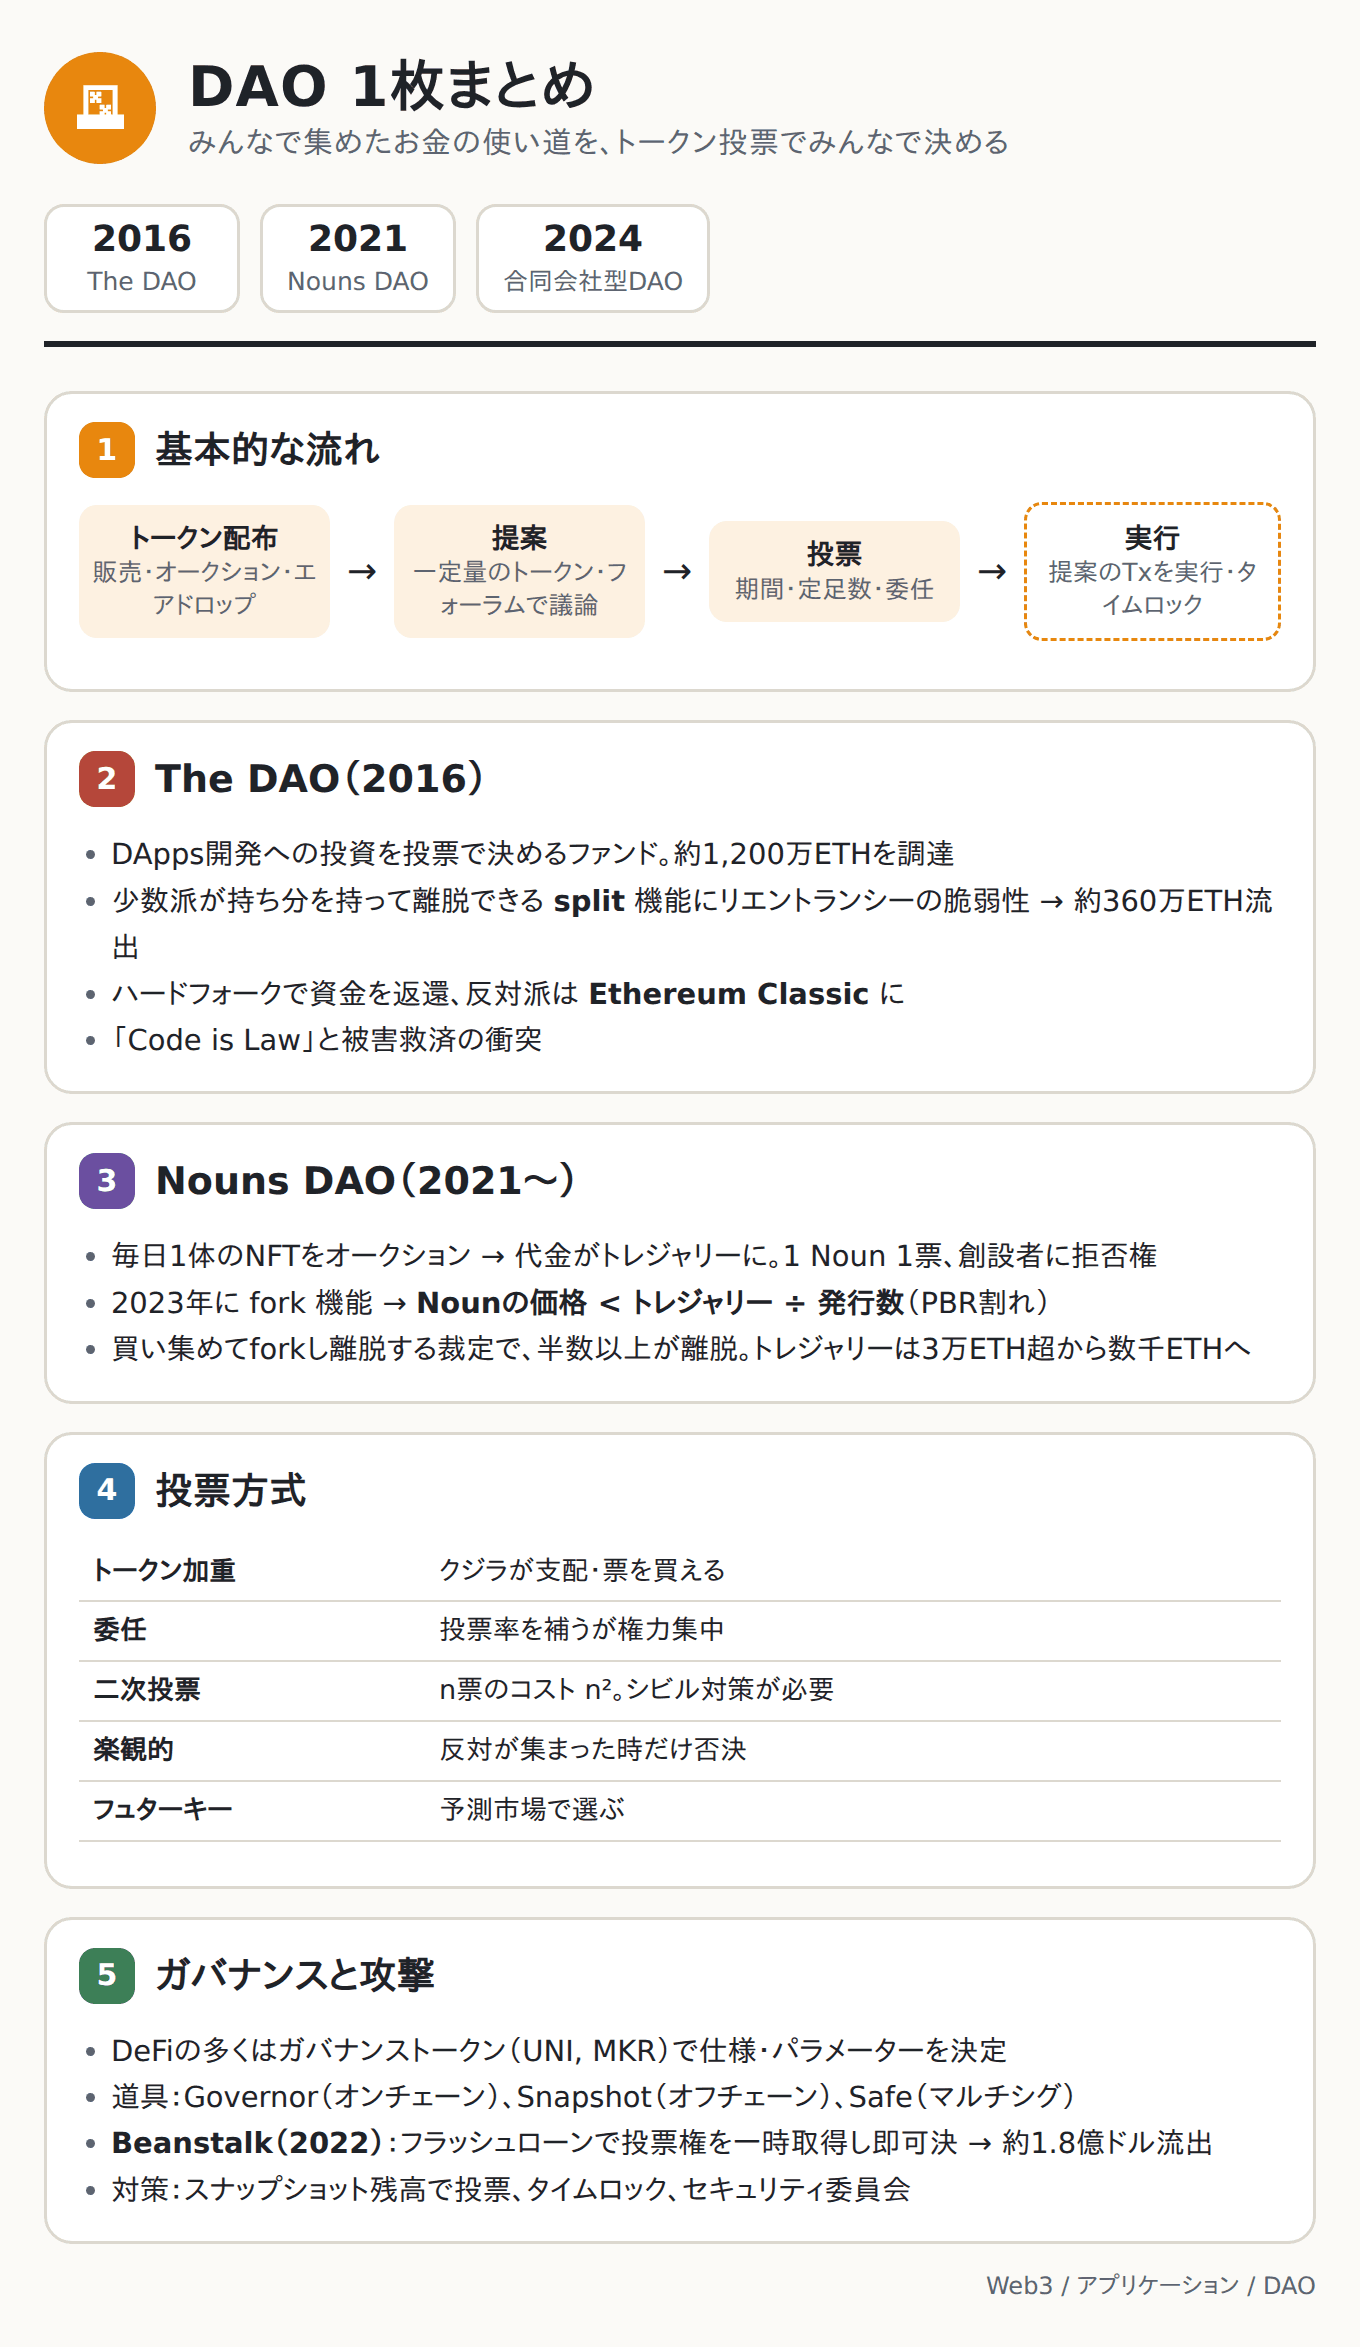

## DAOとは

**DAO（Decentralized Autonomous Organization, 自律分散型組織）** は、スマートコントラクトとトークンによる投票で、資金の使い道やルールの変更を決める組織。明確な定義はないが、Vitalik ButerinはEthereumのホワイトペーパーで次のように説明している。

> 一定のメンバーまたは株主からなる仮想的な事業体であり、例えば67%の多数派が、事業体の資金を使ったりコードを変更したりする権利を持つ。

要するに「みんなで集めたお金の使い道を、みんなで決める」仕組みで、自律分散的に決める対象を

台帳の取引記録（Bitcoin）→ プログラムの実行結果（Ethereum）→ 資金の使い道やルールの変更（DAO）

へと拡張する試みと捉えられる。少なくとも「この手続きでこう決まった」という事実は検証可能な形で残る。

DAOの範囲の捉え方は人によって異なる。

- **狭義**：スマートコントラクトで投票と資金の執行を行うDApps（The DAO, Nouns DAO）
- **広義**：DAppsやプロトコルのガバナンス全般、さらにはオープンソースのコミュニティや町内会のような組織まで

## DAOの基本的な流れ

```mermaid
flowchart LR
    A["トークンの配布<br/>（販売・オークション・エアドロップ）"] --> B["提案<br/>（一定量のトークンが必要）"] --> C["投票<br/>（1トークン1票）"] --> D["実行<br/>（可決された提案のトランザクションを実行）"]
```

| 段階 | 主な設計項目 |
| --- | --- |
| トークンの配布 | 誰に、どれだけ、どうやって配るか。チームや投資家への配分、ロックアップ |
| 提案 | 提案に必要なトークン量、デポジット、事前の議論の場（フォーラム） |
| 投票 | 投票期間、定足数、可決の条件、委任（delegation） |
| 実行 | 可決から実行までの猶予（タイムロック）、拒否権 |

提案の中身は、実行されるトランザクションそのもの（宛先、送金額、呼び出す関数と引数）として記述される。可決されれば、誰でもそのトランザクションを実行できる。

## 事例：The DAO（2016年）

**The DAO** は「DAO」という言葉を最初に使ったプロジェクトで、DAppsの開発プロジェクトへの投資をトークン保有者の投票で決める、自律分散型の投資ファンドだった。

### 設計

- **トークンの配布**：28日間のクラウドセールで、ETHと交換にDAOトークンを配布。約1,200万ETH（当時の総供給量の約14%、約150億円）を集めた
- **提案**：2 ETHのデポジットで提案できる（可決されれば返却）。提案の種類は、DAppsの開発資金の要求、パラメーターの変更、分派（split）
- **投票**：1トークン1票、期間は14日間、定足数は総発行量の20%
- **分派（split）**：多数派の決定に不満な少数派が、自分の持ち分のETHを持って新しいDAOに移れる機能。「いつでも離脱できる」ことが理念として重視されていた

### ハック事件とハードフォーク

2016年6月、split機能の **リエントランシー脆弱性** を突かれ、約360万ETHが攻撃者の子DAOに抜き取られた。トークンをバーンする前にETHの送金が再帰的に繰り返し実行されたのが原因だった（→[スマートコントラクト](../ethereum/smart_contracts.ipynb)）。

splitされたETHは27日間動かせない仕様だったため、その間にEthereumのコミュニティが対応を協議し、**ハードフォークで資金を返金用コントラクトに移す** というステートの強制的な書き換えを行った。これに反対するコミュニティは元のチェーンを維持し、**Ethereum Classic（ETC）** として分岐した。

「Code is Law（コードこそが法）」の理念と、現実の被害救済とが衝突したこの事件は、

- バグの修正をどう行うか（実はこのバグは事前に指摘されていた）
- 攻撃されたときにどう対応するか
- 「みんなで決める」ことの限界

など、DAOを考えるうえで多くの示唆を残した。

## 事例：Nouns DAO（2021年〜）

**Nouns DAO** ([https://nouns.wtf/](https://nouns.wtf/)) は、NFTを使ったDAOで、「最もDAOらしいDAO」とも呼ばれた。

### 設計

- **トークンの配布**：Nounというキャラクターのドット絵NFTを毎日1体発行し、24時間のオークションにかける。落札代金のETHはすべてDAOのトレジャリー（金庫）に入る。最初の5年間は、IDの末尾が0の10体に1体が創設者チームに配られる
- **デザイン**：背景・体・アクセサリー・頭・メガネのパーツの組み合わせを、NFTのIDとブロックの情報から疑似乱数で決め、画像データ自体もオンチェーンに保存する
- **提案**：一定数のNounを持っていれば提案できる。Nounの知名度を上げる活動への資金提供、トレジャリーの運用、DAO自体の改善など
- **投票**：1 Noun 1票。賛成・反対・棄権。定足数は反対票の割合に応じて10〜15%で変動する（Dynamic Quorum）
- **拒否権（Veto）**：創設者が悪意ある提案をキャンセルできる。The DAOの反省を踏まえた安全装置だが、中央集権的な要素でもある

オフチェーンの活動（例えば「Nounsの映画を作った」こと）が本当に行われたかはチェーン上では検証できず、コミュニティへの信頼に頼っている。

### 分裂騒動

2023年に、The DAOのsplitに似た **fork** 機能が導入された。総発行量の20%以上のNounが参加すれば、トレジャリーを按分して新しいDAOに移り、新DAOではNounをバーンして持ち分のETHを引き出せる。

ところが当時はNFT市場が冷え込み、**Nounの市場価格 < トレジャリーの総額 ÷ Noun数** という状態になっていた（株式会社でいえばPBRが1倍を割った状態）。そのため「市場でNounを買い集めてforkに参加し、ETHを引き出せば儲かる」という裁定機会が生まれ、DAOの半数以上がforkして離脱した。その後もforkが繰り返され、トレジャリーは3万ETH超から数千ETHにまで減った。

「いつでも離脱できる」という理念が、裁定取引によって組織そのものを解体させてしまった事例である。

## プロトコルのガバナンス

多くのDeFiプロトコルは **ガバナンストークン** を発行し、仕様やパラメーターの変更をトークン保有者の投票で決めている。

| | Uniswap（UNI） | MakerDAO / Sky（MKR / SKY） |
| --- | --- | --- |
| 発行 | 2020年。総量10億枚のうち60%をコミュニティに配分（過去の利用者へのエアドロップ15%など） | 2017年。100万枚 |
| 主な決定事項 | トレジャリーの使途、手数料率、新バージョンの展開先 | 安定化手数料率、担保の種類、清算のパラメーター |
| プロセス | フォーラムでの議論 → オフチェーンの予備投票（Snapshot）→ オンチェーン投票 | フォーラム → ガバナンス投票 → エグゼクティブ投票（承認投票） |

### ガバナンスの道具

DAOの基本構造はおおむね共通なので、開発を効率化する部品が整備されている。

| 種類 | 例 |
| --- | --- |
| オンチェーン投票のコントラクト | Compound Governor, OpenZeppelin Governor |
| オフチェーン投票（gas不要、ある時点のトークン残高のスナップショットで投票） | Snapshot |
| トレジャリーの管理（マルチシグ） | Safe |
| ノーコードでのDAO作成 | Aragon |
| アップグレード | プロキシパターン（→[スマートコントラクト](../ethereum/smart_contracts.ipynb)） |

## 投票方式

| 方式 | 内容 | 課題 |
| --- | --- | --- |
| トークン加重投票（1トークン1票） | 最も一般的 | 大口保有者（クジラ）が支配する。投票権の売買が可能 |
| 委任投票 | 自分の投票権を信頼できる代表者（デリゲート）に委ねる | 投票率の低さを補えるが、少数のデリゲートに権力が集中する |
| 二次投票（Quadratic Voting） | $n$ 票を投じるコストが $n^2$。少数の強い選好も反映できる | 複数のアドレスに分割する（シビル攻撃）と回避できるため、本人確認が必要 |
| コンビクション投票 | 投票を継続した期間に応じて票の重みが増す | 結果が出るまで時間がかかる |
| 楽観的ガバナンス | 提案は原則として通り、一定期間に反対が集まった場合だけ否決する | 監視を怠ると悪意ある提案が通る |
| フュターキー（Futarchy） | 提案を実行した場合としない場合の予測市場を立て、トークン価格が高くなると予測される方を選ぶ（Hanson） | 実例が少ない（→[予測市場](./prediction_markets.ipynb)） |

### ガバナンス攻撃

トークン加重投票では、投票権をお金で買えるため攻撃の対象になる。

2022年の **Beanstalk** 事件では、攻撃者がフラッシュローンで約10億ドル分の資産を借りてガバナンストークンを一時的に大量取得し、トレジャリーの資金を自分に送る提案を即座に可決・実行して、約1億8,000万ドル相当を流出させた。

対策として、

- 投票に使えるのは、提案作成時点（スナップショット）のトークン残高のみとする
- 可決から実行までに **タイムロック**（猶予期間）を設け、悪意ある提案が通っても資金を引き上げる時間を確保する
- 緊急時に提案を停止できるセキュリティ委員会を置く

などが取られている。

## DAOの法的な位置づけ

DAOは法人格を持たないことが多く、メンバーが無限責任を負うリスクや、契約・納税の主体になれない問題がある。

- 米国のワイオミング州などでは、DAOをLLC（有限責任会社）として登録できる制度がある
- 日本では2024年4月の制度改正で、**合同会社型DAO** として、社員権をトークン化して発行・流通させやすくなった

## 参考文献

- Buterin, V. (2014). [DAOs, DACs, DAs and More: An Incomplete Terminology Guide](https://blog.ethereum.org/2014/05/06/daos-dacs-das-and-more-an-incomplete-terminology-guide).
- Jentzsch, C. (2016). [Decentralized Autonomous Organization to Automate Governance](https://lawofthelevel.lexblogplatformthree.com/wp-content/uploads/sites/187/2017/07/WhitePaper-1.pdf). （The DAOのホワイトペーパー）
- [Nouns Center](https://nouns.center/)
- Buterin, V. (2021). [Moving beyond coin voting governance](https://vitalik.eth.limo/general/2021/08/16/voting3.html).
- Weyl, E. G., Ohlhaver, P. & Buterin, V. (2022). [Decentralized Society: Finding Web3's Soul](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4105763).